In [9]:
import torch

from cryosim.pdbtools import PDB
from cryosim.plotting_tools import plot3d
from cryosim.potential import PotentialBuilder
import mrcfile
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create 3D scattering potential

In [59]:
# fetch pdb file
pdb_code = "7vd8"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")
# pdb = PDB(
#     "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# )

Assemblies available: 1
7vd8: Fetching default Biological Assembly 1
File already exists: ../pdb-data/7vd8-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [66]:
# Samples 3D scattering potential onto specified grid
n = 130  # number of pixels per axis
dx = 1  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [67]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/6 [00:00<?, ?it/s]

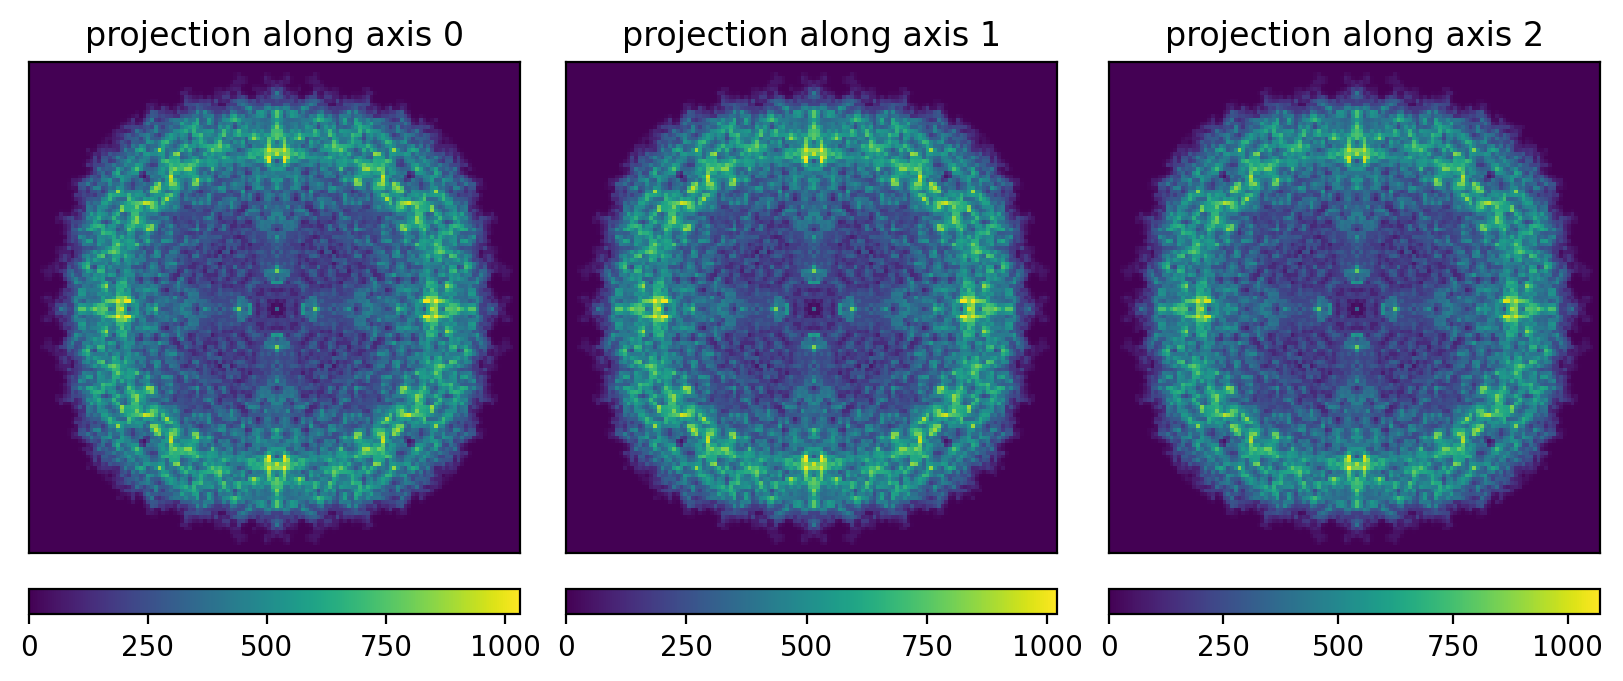

In [68]:
plot3d(V)

In [69]:
with mrcfile.new(
    "/mnt/cbis/home/e0788253/polnet/data/mrc/apoferritin_7VD8_1A.mrc", overwrite=True
) as mrc:
    mrc.set_data(np.asarray(V))